<a href="https://colab.research.google.com/github/AndresT3086/saberPRO-prediction/blob/main/99_modelo_solucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#INSTALAR LIBRERIAS
pip install pandas numpy scikit-learn catboost lightgbm xgboost

In [ ]:
#IMPORTS
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report

from catboost import CatBoostClassifier, Pool
from lightgbm import LGBMClassifier
from lightgbm.callback import early_stopping
from xgboost import XGBClassifier

In [1]:
#cargar datos
print('Cargando datos...')

train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')


train = train.dropna(subset=['RENDIMIENTO_GLOBAL']).reset_index(drop=True)

Cargando datos...


NameError: name 'pd' is not defined

In [ ]:
#TARGET + LABEL ENCODER
test_ids = test['ID'].copy()
y_raw = train['RENDIMIENTO_GLOBAL'].copy()
le = LabelEncoder()
y = le.fit_transform(y_raw).astype(int)
num_classes = len(le.classes_)
X_base      = train.drop(['ID', 'RENDIMIENTO_GLOBAL'], axis=1)
X_base_test = test.drop(['ID'], axis=1)

In [ ]:
#IMPUTACIÓN SIMPLE (MEDIA / 'MISSING')

print("\nImputando valores faltantes (media/'MISSING')...")

num_cols = X_base.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_base.select_dtypes(include=['object']).columns.tolist()

for c in num_cols:
    media = X_base[c].mean()
    X_base[c] = X_base[c].fillna(media)
    if c in X_base_test.columns:
        X_base_test[c] = X_base_test[c].fillna(media)

for c in cat_cols:
    X_base[c] = X_base[c].fillna('MISSING')
    if c in X_base_test.columns:
        X_base_test[c] = X_base_test[c].fillna('MISSING')

In [ ]:
#ENCODING SIMPLE (Ordinal Encoding + FIX de tipo)
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_all_oe = pd.concat([X_base[cat_cols], X_base_test[cat_cols]], axis=0)
oe.fit(X_all_oe)

X_cb = X_base.copy()
X_cb_test = X_base_test.copy()

X_cb[cat_cols] = oe.transform(X_base[cat_cols])
X_cb_test[cat_cols] = oe.transform(X_base_test[cat_cols])

for c in cat_cols:
    X_cb[c] = X_cb[c].astype(int)
    X_cb_test[c] = X_cb_test[c].astype(int)

cat_idx = [X_cb.columns.get_loc(c) for c in cat_cols]

In [ ]:
# CONFIGURACIÓN DE MODELOS BASE

class_weights = [1.0, 1.0, 1.7, 1.7]


cb_params = {'loss_function': 'MultiClass', 'eval_metric': 'Accuracy', 'task_type': "GPU", 'devices': '0', 'learning_rate': 0.04, 'depth': 9, 'l2_leaf_reg': 4, 'bootstrap_type': "Bayesian", 'bagging_temperature': 1.2, 'class_weights': class_weights, 'random_state': 77, 'verbose': 0, 'n_estimators': 1200}
lgbm_params = {'objective': 'multiclass', 'metric': 'multi_logloss', 'num_class': num_classes, 'n_estimators': 1500, 'learning_rate': 0.05, 'num_leaves': 31, 'random_state': 42, 'n_jobs': -1, 'verbose': -1, 'class_weight': {c: w for c, w in enumerate(class_weights)}}
xgb_params = {'objective': 'multi:softprob', 'eval_metric': 'mlogloss', 'num_class': num_classes, 'n_estimators': 1000, 'learning_rate': 0.05, 'max_depth': 7, 'random_state': 42, 'use_label_encoder': False, 'tree_method': 'hist', 'n_jobs': -1}


base_models = [
    ('catboost', CatBoostClassifier(**cb_params), True), # use_es=True
    ('lightgbm', LGBMClassifier(**lgbm_params), True),
    ('xgboost', XGBClassifier(**xgb_params), False), # use_es=False
]

indicator_cols = ['INDICADOR_1', 'INDICADOR_2', 'INDICADOR_3', 'INDICADOR_4']
N_INDICATORS = len(indicator_cols)

N_META_FEATURES = (len(base_models) * num_classes) + N_INDICATORS

In [ ]:
# STACKING ENSEMBLE (5-FOLD CROSS-VALIDATION)

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

X_meta_train = np.zeros((X_cb.shape[0], N_META_FEATURES))
test_pred_folds = np.zeros((len(base_models), X_cb_test.shape[0], num_classes))

print(f"\n=== ENTRENANDO BASE MODELS CON {N_SPLITS}-FOLD CV (3 GBDT) ===")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cb, y)):
    print(f"\n--- Fold {fold+1}/{N_SPLITS} ---")

    X_train = X_cb.iloc[train_idx].copy()
    X_val = X_cb.iloc[val_idx].copy()
    y_train = y[train_idx]


    X_val_indicators = X_val[indicator_cols].values


    for model_idx, (name, model, use_es) in enumerate(base_models):
        print(f"  Entrenando {name}...")

        if name == 'catboost':
            train_pool = Pool(X_train, y_train, cat_features=cat_idx)
            val_pool   = Pool(X_val, y[val_idx], cat_features=cat_idx)
            model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=100 if use_es else None)
            proba_val = model.predict_proba(X_val)
        elif name == 'lightgbm':
            callbacks_list = [early_stopping(stopping_rounds=100, verbose=False)] if use_es else []
            model.fit(X_train, y[train_idx],
                      eval_set=[(X_val, y[val_idx])] if use_es else None,
                      callbacks=callbacks_list,
                      categorical_feature=cat_idx)
            proba_val = model.predict_proba(X_val)
        elif name == 'xgboost':
            model.fit(X_train, y[train_idx])
            proba_val = model.predict_proba(X_val)


        start_col = model_idx * num_classes
        X_meta_train[val_idx, start_col:start_col + num_classes] = proba_val


        proba_test = model.predict_proba(X_cb_test)
        test_pred_folds[model_idx, :, :] += proba_test


    START_INDICATOR_COL = len(base_models) * num_classes
    X_meta_train[val_idx, START_INDICATOR_COL:N_META_FEATURES] = X_val_indicators



In [ ]:
# ENTRENAR META LEARNER (CAPA 2)

print("\n=== ENTRENANDO META LEARNER (LGBMClassifier - Potente) ===")

meta_learner = LGBMClassifier(
    objective='multiclass',
    metric='multi_logloss',
    num_class=num_classes,
    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    random_state=42,
    n_jobs=-1,

    class_weight='balanced',
    verbose=-1
)

meta_learner.fit(X_meta_train, y)

In [ ]:
# Evaluación del Stacking en las predicciones OOF (pseudo-validación)
y_pred_meta_oof = meta_learner.predict(X_meta_train)
acc_oof = accuracy_score(y, y_pred_meta_oof)
print(f"\nAccuracy ensemble OOF (Stacking, LGBM Meta Learner): {acc_oof:.4f}")


# Reporte de clasificación OOF
labels_present = np.unique(y)
target_names = le.inverse_transform(labels_present)
print("\nReporte ensemble OOF:")
print(classification_report(
    y,
    y_pred_meta_oof,
    labels=labels_present,
    target_names=target_names
))

In [ ]:
# PREDICCIÓN FINAL EN TEST + SUBMISSION

print("\n=== GENERANDO PREDICCIONES FINALES EN TEST ===")

test_pred_mean = test_pred_folds / N_SPLITS

X_meta_probas = test_pred_mean.transpose(1, 0, 2).reshape(X_cb_test.shape[0], -1)

X_test_indicators = X_cb_test[indicator_cols].values

X_meta_test_final = np.hstack([X_meta_probas, X_test_indicators])

y_pred_test_num = meta_learner.predict(X_meta_test_final)
y_pred_test_lbl = le.inverse_transform(y_pred_test_num)

submission = pd.DataFrame({
    'ID': test_ids,
    'RENDIMIENTO_GLOBAL': y_pred_test_lbl
})

nombre_archivo = 'submission_stacking_elite_v12.csv'
submission.to_csv(nombre_archivo, index=False)

print(f"\n Archivo de submission creado: {nombre_archivo}")
print(submission.head())

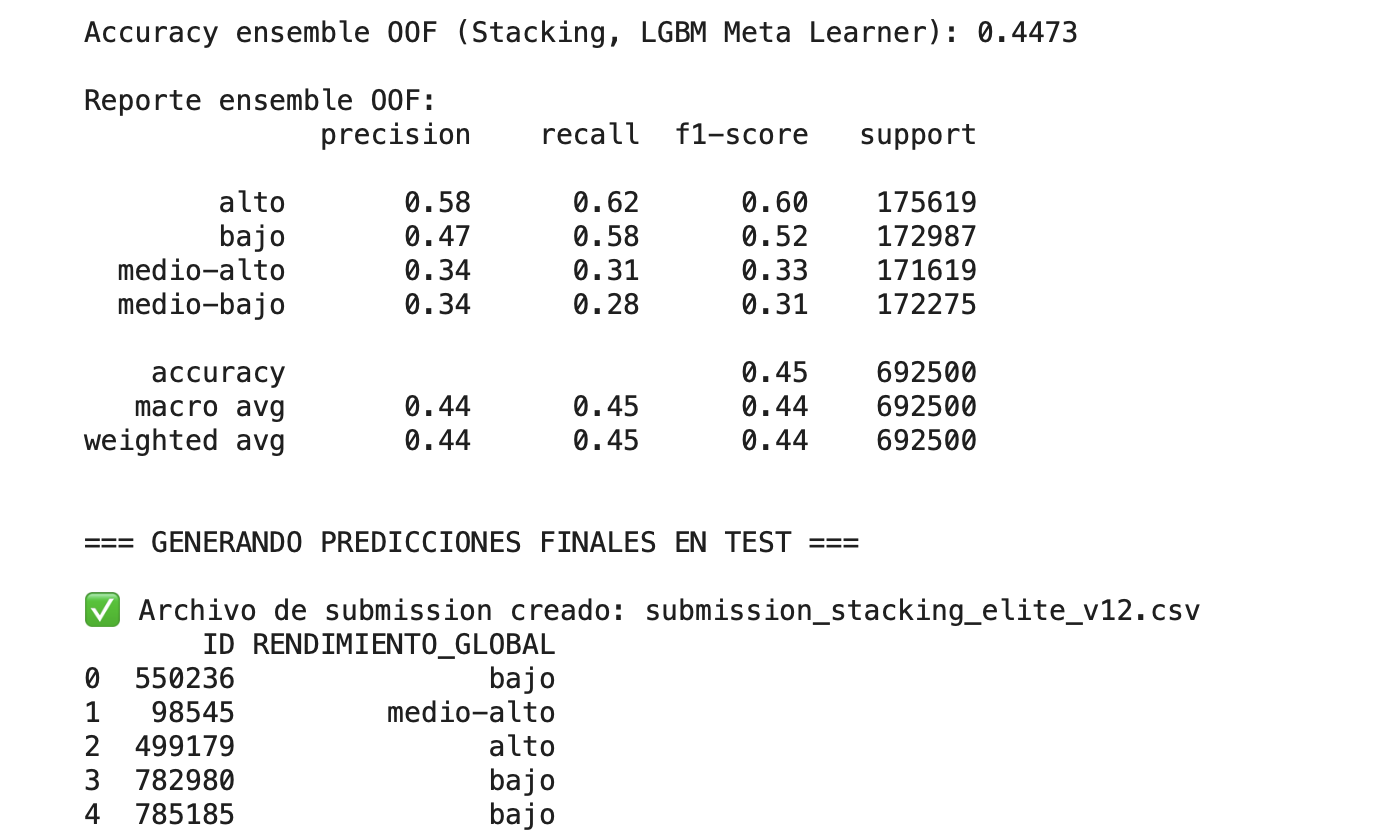